<a href="https://colab.research.google.com/github/caashka/programming_big_data/blob/main/%D0%94%D0%9F%D0%9E_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D1%80%D0%B0%D1%81%D1%82%D1%80%D0%BE%D0%B2%D1%8B%D0%BC%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B2_Rasterio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №3. Работа с растровыми данными в Rasterio**

---

**Данные для обработки:**

- Одноканальное изображение (ЦМР): https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
- Мультиспектральное изображение (Landsat): https://github.com/opengeos/datasets/releases/download/raster/cog.tif

In [66]:
%%capture
%pip install rasterio fiona folium matplotlib mapclassify

### **Задание 1. Чтение и исследование растровых данных**



1. Откройте одноканальное изображение ЦМР с использованием `rasterio`.


In [67]:
import rasterio

dem_path = "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
with rasterio.open(dem_path) as dem_src:
    dem = dem_src.read(1)
dem

array([[ 579,  582,  591, ..., 2014, 2029, 2040],
       [ 595,  603,  613, ..., 1986, 1995, 2010],
       [ 609,  622,  628, ..., 1964, 1987, 2011],
       ...,
       [ 544,  541,  569, ...,  451,  446,  440],
       [ 530,  532,  566, ...,  455,  446,  437],
       [ 520,  519,  544, ...,  447,  450,  447]], dtype=int16)

2. Извлеките и выведите метаданные растра, включая СК, разрешение, границы, количество каналов и типы данных.


In [68]:
print("Метаданные ЦМР:")
print(f"Система координат (СК): {dem_src.crs}")
print(f"Разрешение: {dem_src.res}")
print(f"Границы: {dem_src.bounds}")
print(f"Количество каналов: {dem_src.count}")
print(f"Тип данных: {dem_src.dtypes[0]}")

Метаданные ЦМР:
Система координат (СК): EPSG:3857
Разрешение: (90.0, 89.99579177642138)
Границы: BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)
Количество каналов: 1
Тип данных: int16


3. Отобразите ширину и высоту растра, а также типы данных пикселей, чтобы понять размеры сетки и структуру данных.

In [69]:
print(f"Ширина растра: {dem_src.width}")
print(f"Высота растра: {dem_src.height}")
print(f"Тип данных пикселей: {dem_src.dtypes[0]}")

Ширина растра: 4269
Высота растра: 3113
Тип данных пикселей: int16


---



### **Задание 2. Визуализация и манипулирование растровыми каналами**



1. Визуализируйте одноканальное изображение ЦМР с использованием пользовательской цветовой карты (например, cmap='terrain').


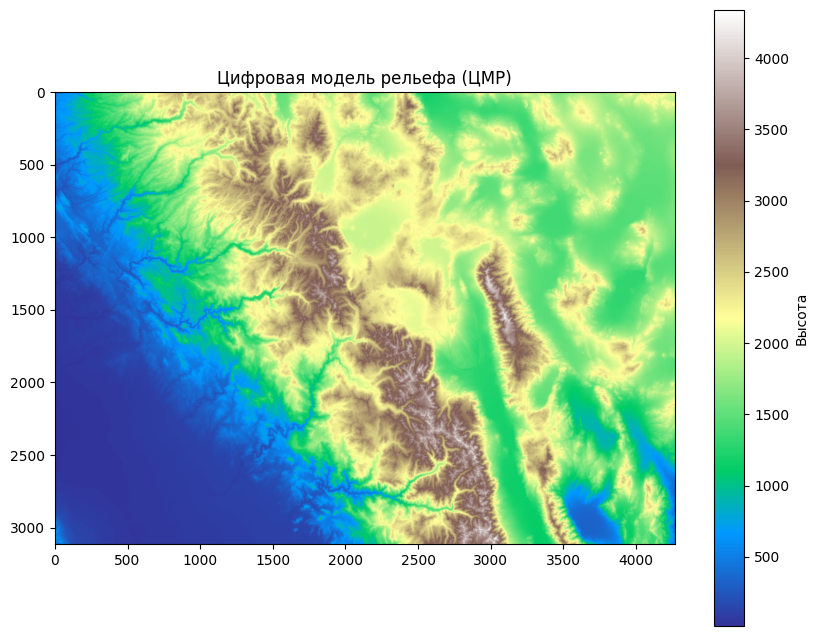

In [70]:
import matplotlib.pyplot as plt

with rasterio.open(dem_path) as dem_src:
    dem = dem_src.read(1)

plt.figure(figsize=(10, 8))
plt.imshow(dem, cmap='terrain')
plt.colorbar(label='Высота')
plt.title('Цифровая модель рельефа (ЦМР)')
plt.show()

2. Откройте мультиспектральное изображение и визуализируйте первый канал с использованием подходящей цветовой карты.


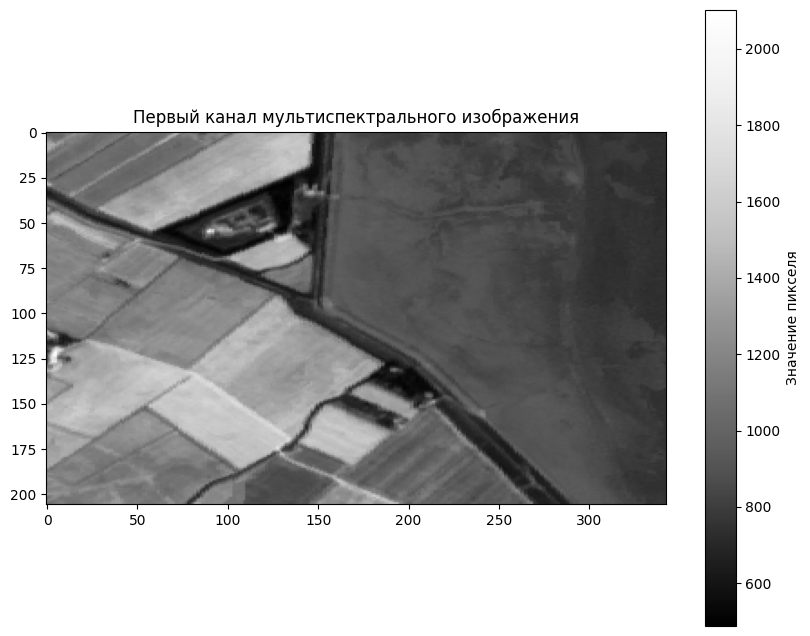

In [71]:
multispectral_path = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"
with rasterio.open(multispectral_path) as multispectral_src:
    band1 = multispectral_src.read(1)

plt.figure(figsize=(10, 8))
plt.imshow(band1, cmap='Greys_r')
plt.colorbar(label='Значение пикселя')
plt.title('Первый канал мультиспектрального изображения')
plt.show()

3. Объедините несколько каналов из мультиспектрального изображения (например, Красный, Зеленый и Синий) и совместите их в один массив для создания RGB-композитного изображения.

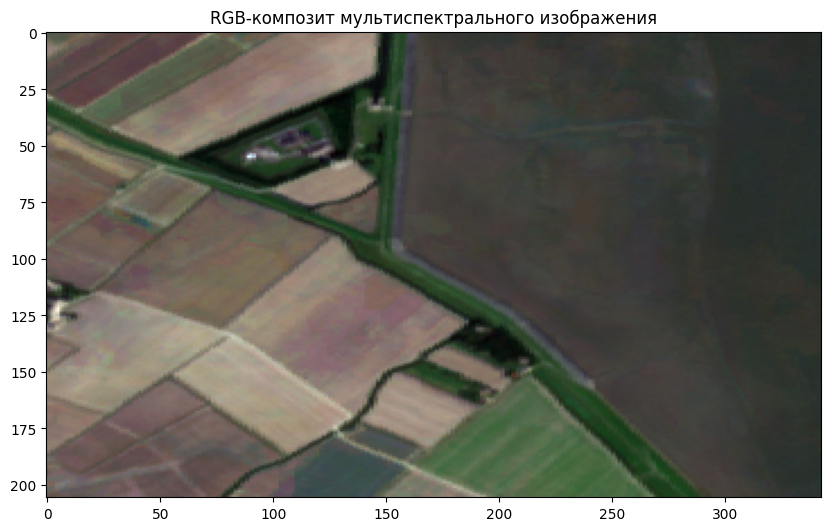

In [72]:
import numpy as np

src =  rasterio.open(multispectral_path)
red = src.read(1)
green = src.read(2)
blue = src.read(3)

def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm

red_norm = normalize(red)
green_norm = normalize(green)
blue_norm = normalize(blue)

rgb = np.dstack((red_norm, green_norm, blue_norm))

plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.title('RGB-композит мультиспектрального изображения')
plt.show()

---



### **Задание 3. Обрезка растра с использованием индексации массива**



1. Откройте мультиспектральное изображение и обрежьте его с использованием спискового среза (указав диапазоны строк и столбцов).


In [73]:
src.meta

{'driver': 'GTiff',
 'dtype': 'float64',
 'nodata': None,
 'width': 343,
 'height': 206,
 'count': 4,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(8.983152841195215e-05, 0.0, 6.860074498707138,
        0.0, -8.983152841195215e-05, 53.41634207654228)}

In [74]:
data = src.read()
print('До - ', data.shape)
subset = data[:, 100:200, 150:250]
subset_red = normalize(subset[0])
subset_green = normalize(subset[1])
subset_blue = normalize(subset[2])
rgb_subset = np.dstack((subset_red, subset_green, subset_blue))
test = np.dstack((subset[1], subset[2], subset[3])).clip(0, 1)
print('После - ', rgb_subset.shape)

До -  (4, 206, 343)
После -  (100, 100, 3)


2. Визуализируйте обрезанную часть изображения с использованием matplotlib, чтобы убедиться в корректном результате.


>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



Включите следующую функцию в ваш код:

```python
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
```

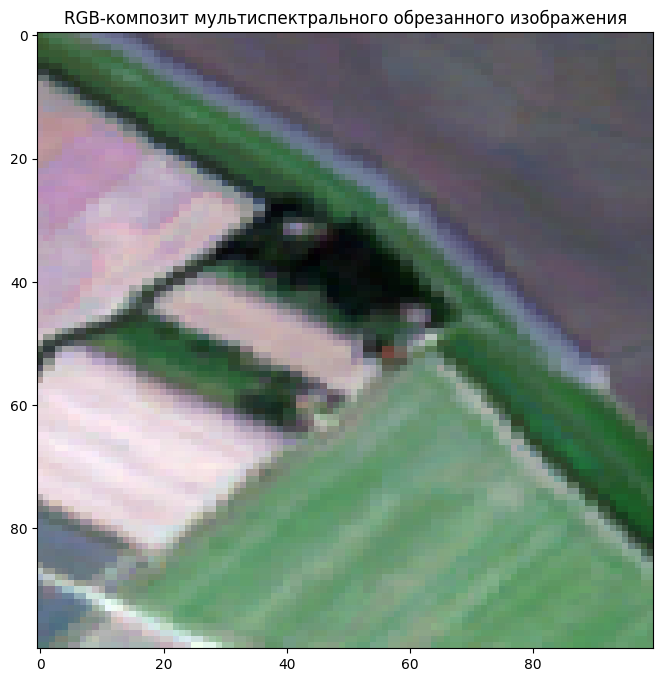

In [75]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb_subset)
plt.title('RGB-композит мультиспектрального обрезанного изображения')
plt.show()

3. Сохраните обрезанное подмножество растра в новый файл с именем `clipped_multispectral.tif`.

In [76]:
with rasterio.open(
    "clipped_multispectral.tif",
    "w",
    driver="GTiff",
    height=subset.shape[1],
    width=subset.shape[2],
    count=subset.shape[0],
    dtype=subset.dtype,
    compress="lzw",
) as dst:
    dst.write(subset)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


---



### **Задание 4. Вычисление NDWI (калькуляция каналов)**



1. Откройте мультиспектральное изображение и извлеките каналы Green (Зеленый) и Ближний инфракрасный (NIR).


In [77]:
green = src.read(2)
nir = src.read(4)

2. Вычислите Нормализованный разностный водный индекс ([NDWI](https://en.wikipedia.org/wiki/Normalized_difference_water_index)) по формуле:

    NDWI = (Green - NIR) / (Green + NIR)

In [78]:
ndwi = (green - nir) / (green + nir)
ndwi = ndwi.clip(-1, 1)

3. Визуализируйте результат NDWI с использованием цветовой карты, подходящей для воды (например, cmap='Blues'), чтобы выделить водные объекты.


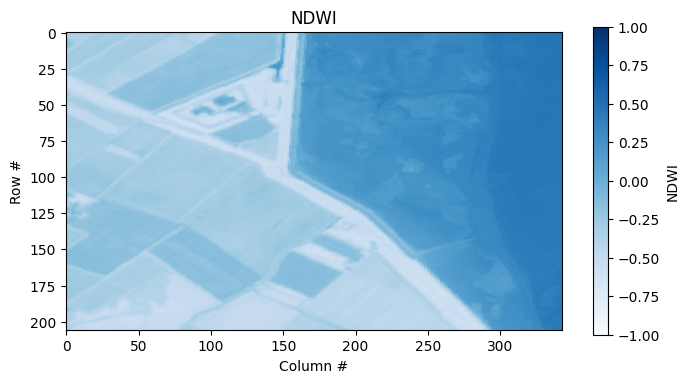

In [79]:
plt.figure(figsize=(8, 8))
plt.imshow(ndwi, cmap="Blues", vmin=-1, vmax=1)
plt.colorbar(label="NDWI", shrink=0.5)
plt.title("NDWI")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()



4. Сохраните полученное изображение NDWI как новый растровый файл с именем ndwi.tif.

In [65]:
with rasterio.open(multispectral_path) as src:
    profile = src.profile

print(profile)
profile.update(dtype=rasterio.float32, count=1, compress="lzw")
print()
print(profile)

output_raster_path = "ndwi.tif"

with rasterio.open(output_raster_path, "w", **profile) as dst:
    dst.write(ndwi, 1)
print(f"Растровые данные были записаны в файл: {output_raster_path}")

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 343, 'height': 206, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 6.860074498707138,
       0.0, -8.983152841195215e-05, 53.41634207654228), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'deflate', 'interleave': 'pixel'}

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 343, 'height': 206, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS

---



### **Задание 5. Перепроецирование растровых данных**



1. Перепроецируйте одноканальный растр ЦМР из его исходной СК в EPSG:4326 (WGS 84) с использованием функции `rasterio.warp.reproject`.


In [83]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

dst_crs = "EPSG:4326"
output_reprojected_path = "reprojected_dem.tif"

with rasterio.open(dem_path) as src:

    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    profile = src.profile
    profile.update(crs=dst_crs, transform=transform, width=width, height=height)

    with rasterio.open(output_reprojected_path, "w", **profile) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest,
            )

print(f"Перепроецированный растр сохранен как: {output_reprojected_path}")

Перепроецированный растр сохранен как: reprojected_dem.tif


2. Сохраните перепроецированный растр в новый файл GeoTIFF с именем `reprojected_dem.tif`.


In [ ]:
# Ваш код

3. Визуализируйте как исходный, так и перепроецированный наборы данных ЦМР, чтобы сравнить, как перепроецирование влияет на пространственное покрытие и разрешение.

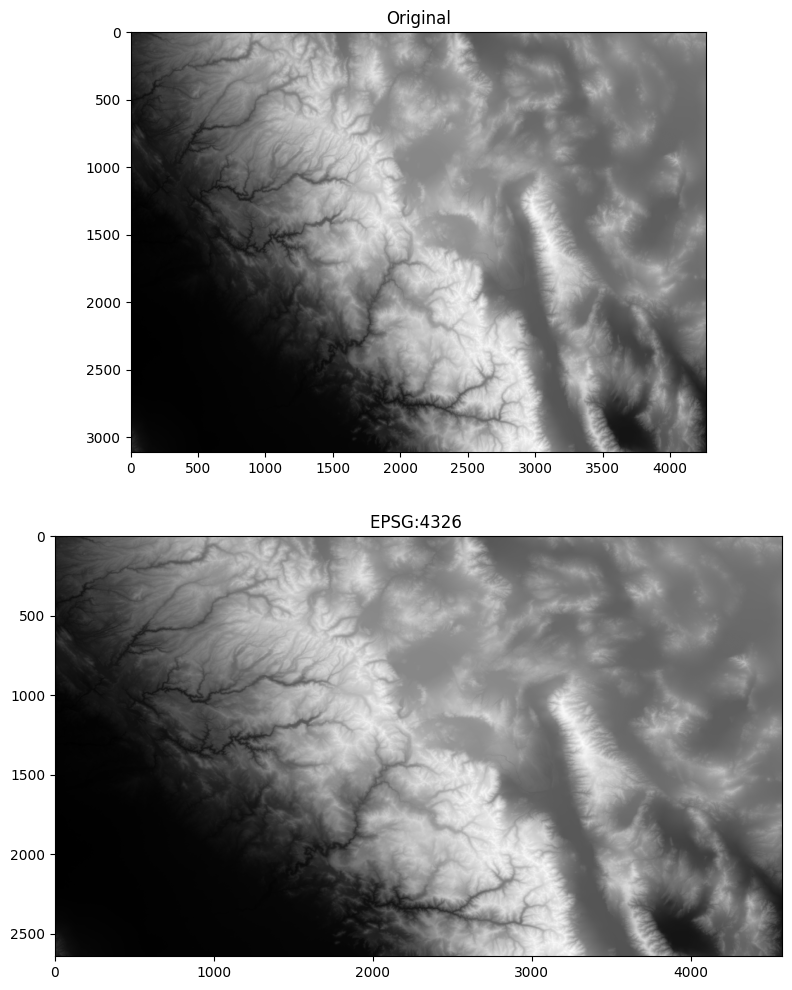

In [87]:
src = rasterio.open(dem_path).read(1)
dst = rasterio.open("reprojected_dem.tif").read(1)

plt.figure(figsize=(24, 12))
plt.subplot(2, 1, 1)
plt.imshow(src, cmap='Greys_r')
plt.title('Original')
plt.subplot(2, 1, 2)
plt.imshow(dst, cmap='Greys_r')
plt.title('EPSG:4326 ')
plt.show()

---